In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [13]:
# Load the Iris dataset

iris = load_iris()

# Convert the dataset into a DataFrame
df = pd.DataFrame(iris.data, columns=iris.feature_names)

# Add the target column
df['species'] = iris.target

# Display the first 5 rows
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [ ]:
# Check the shape of the dataset
print("Number of rows and columns:", df.shape)

# Check the column names
print("\nColumn names:")
print(df.columns)

# Check basic information about the dataset
print("\nDataset information:")
df.info()


Number of rows and columns: (150, 5)

Column names:
Index(['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)',
       'petal width (cm)', 'species'],
      dtype='object')

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   species            150 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 6.0 KB


In [ ]:
# Check for missing values

print("Missing values in each column:")
print(df.isnull().sum())

Missing values in each column:
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
species              0
dtype: int64


In [14]:
# Convert target numbers into flower species names

df['species'] = df['species'].map({
    0: 'Setosa',
    1: 'Versicolor',
    2: 'Virginica'
})

# Display the first 5 rows
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,Setosa
1,4.9,3.0,1.4,0.2,Setosa
2,4.7,3.2,1.3,0.2,Setosa
3,4.6,3.1,1.5,0.2,Setosa
4,5.0,3.6,1.4,0.2,Setosa


In [15]:
# Separate features (X) and target (y)

X = df.drop('species', axis=1)
y = df['species']

print("Features (X):")
print(X.columns)

print("\nTarget (y):")
print("species")

Features (X):
Index(['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)',
       'petal width (cm)'],
      dtype='object')

Target (y):
species


In [16]:
# Split the data into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)


Training data: (120, 4)
Testing data: (30, 4)


In [21]:
# Train the Logistic Regression model

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

print("Model training completed successfully!")


Model training completed successfully!


In [22]:
# Make predictions on the test data

y_pred = model.predict(X_test)

print("First 10 predictions:")
print(y_pred[:10])

First 10 predictions:
['Versicolor' 'Setosa' 'Virginica' 'Versicolor' 'Versicolor' 'Setosa'
 'Versicolor' 'Virginica' 'Versicolor' 'Versicolor']


In [23]:
# Calculate the accuracy of the model

accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy:", accuracy)
print("Accuracy Percentage:", accuracy * 100, "%")

Model Accuracy: 1.0
Accuracy Percentage: 100.0 %


In [24]:
# Create a confusion matrix

cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


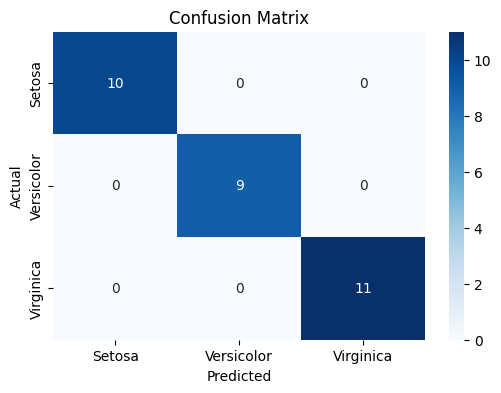

In [25]:
# Visualize the confusion matrix

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Setosa', 'Versicolor', 'Virginica'],
            yticklabels=['Setosa', 'Versicolor', 'Virginica'])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [26]:
# Generate the classification report

report = classification_report(y_test, y_pred)

print("Classification Report:")
print(report)

Classification Report:
              precision    recall  f1-score   support

      Setosa       1.00      1.00      1.00        10
  Versicolor       1.00      1.00      1.00         9
   Virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



In [27]:
# Conclusion

print("Conclusion:")
print("The Iris Flower Classification model was successfully built using Logistic Regression.")
print("The model achieved an accuracy of 100%.")
print("The model uses sepal and petal measurements to classify Iris flowers")
print("into Setosa, Versicolor, and Virginica species.")

Conclusion:
The Iris Flower Classification model was successfully built using Logistic Regression.
The model achieved an accuracy of 100%.
The model uses sepal and petal measurements to classify Iris flowers
into Setosa, Versicolor, and Virginica species.
